# Phase 2: Evolutionary Algorithm Optimization — `EA_Optimization.ipynb`

**Team 1 — NYC Taxi Trip Duration**

---
## Words We Use in This Notebook (Glossary)

Before reading the code, here are the key terms you will see throughout this notebook. Each one is explained in simple language.

| Term | What It Means |
|------|---------------|
| **Model** | A program that learns from data to make predictions. In this notebook, the model tries to predict taxi trip duration. |
| **Baseline model** | A simple model we use for comparison. If our more complex model cannot beat the baseline, it is not useful. |
| **Neural network** | A type of model that learns patterns by adjusting many small numbers. It can learn complex relationships in the data. |
| **Hyperparameter** | A setting we choose *before* training (like learning rate or number of layers). The model does not learn these automatically. |
| **Evolutionary Algorithm (EA)** | A method that searches for good solutions by trying many options and improving them over time, similar to natural selection. |
| **Genetic Algorithm (GA)** | A type of EA that uses ideas like selection, crossover, and mutation to improve solutions. |
| **Individual / Candidate** | One specific set of hyperparameters being tested. Think of it as one “contestant.” |
| **Population** | A group of candidates tested in one round. |
| **Generation** | One round of the algorithm. Each generation creates new candidates based on the best previous ones. |
| **Fitness** | A score that tells us how good a candidate is. In this notebook, fitness = validation R² (higher is better). |
| **Selection** | Choosing the best candidates to create the next generation. |
| **Crossover** | Combining two candidates to make a new one (like mixing traits from parents). |
| **Mutation** | Making small random changes to a candidate to explore new possibilities. |
| **Elitism** | Keeping the best candidates unchanged so we do not lose good solutions. |
| **Training set** | The data used to teach the model (70% of the data). |
| **Validation set** | Data used to compare candidates during tuning (15%). It helps choose good settings but is not the final test. |
| **Test set** | Data saved for the final check only (15%). It is used once at the end to measure true performance. |
| **R² (R-squared)** | A score that shows how well the model explains the data. 1.0 = perfect. 0.0 = no better than guessing the average. It can be negative if the model performs very poorly. Higher is better. |
| **MAPE (Mean Absolute Percentage Error)** | The average percent error of predictions. For example, 10% means predictions are off by about 10% on average. Lower is better. |
| **RMSE (Root Mean Squared Error)** | Measures prediction error in seconds. Large mistakes are punished more heavily. Lower is better. |
| **MAE (Mean Absolute Error)** | The average prediction error in seconds. All errors are treated equally. Lower is better. |
| **Bootstrap confidence interval** | A method that repeats the evaluation many times using slightly different samples to check if results are reliable. If the interval does not include zero, the improvement is likely real. |
| **Log-transform** | Applying `log(x+1)` to make very large trip durations smaller. This helps the model learn both short and long trips more evenly. |
| **Z-score scaling** | Adjusting values so features have similar scale (mean ≈ 0, spread ≈ 1). This helps the model train more smoothly. |

---
### What this notebook does

In this notebook, we use an **Evolutionary Algorithm (EA)** to improve a **neural network model** that predicts how long a taxi trip will take in New York City.

The EA helps us choose the best **hyperparameters**(for example: learning rate, number of layers, and dropout).

---

### How the idea works

Instead of guessing good settings, we use a process inspired by biology:

- We start with many different possible settings (*candidates*)
- We test how well each one performs using validation data
- We keep the best ones and combine them to create new settings
- We repeat this process over many rounds (*generations*)

Over time, the settings “evolve” to become better and better.

---

### Why we do this

A neural network’s performance depends heavily on its settings.

- Bad settings → poor predictions  
- Good settings → better accuracy  

The Evolutionary Algorithm helps us **search for better settings automatically** instead of guessing.

---

### What we compare at the end

At the end of the notebook, we compare:

- A **baseline model** (a simple model used for comparison, such as Linear Regression)
- The **EA-optimized model** (the improved model found using evolution)

We evaluate both models using metrics like:

- **R²** (how well the model explains the data)
- **MAPE** (average percent error)

This helps us answer an important question:

👉 *Was the extra computation from the EA worth it?*

---
## How to Run This Notebook

Follow these steps to run the notebook from start to finish:

1. **Open the notebook in NRP JupyterHub (required for final results).**  
   You may test locally, but all final experiments must be run on NRP to ensure fairness and reproducibility.

2. **Check your compute device.**  
   The first code cell will show whether you are using a GPU or CPU.  
   - GPU: faster (recommended)  
   - CPU: works correctly but may take longer  

3. **Run every cell in order, from top to bottom.**  
   In Jupyter, click `Kernel → Restart & Run All`.

4. **Do not skip cells or run them out of order.**  
   Each step depends on previous outputs.

5. **Output files** (plots, logs, and saved models) will be created automatically in the `../artifacts/phase2/` folder.

6. **Expected runtime:**  
   The full Evolutionary Algorithm run may take **15–60 minutes** depending on hardware.

---

### ⚠️ Quick Test Mode (Optional)

If you only want to check that the notebook runs correctly:

- You may temporarily reduce:
  - `GENERATIONS` (e.g., 2)
  - `POPULATION_SIZE` (e.g., 5)

👉 **Important:** These reduced settings are only for testing.  
You must restore the original values before generating final results, since the project requires a fixed compute budget for fair comparison.


---
## Fair Evaluation Rules

To make sure our results are honest and trustworthy, we follow strict rules about how data is used.

We use a **70% / 15% / 15% split** (train / validation / test).

| Data Split | What It Is Used For | When It Is Touched |
|---|---|---|
| **Training set (70%)** | Teaching the neural network | Every time a candidate is trained |
| **Validation set (15%)** | Scoring candidates during the EA search (**fitness = validation R²**) | During EA evolution only |
| **Test set (15%)** | Getting the final, honest score | **Exactly once**, after the EA is completely finished |

---

### Why these rules matter

- If we used the test set to pick the best candidate, we would be **cheating** — the final score would look better than it really is.
- The validation set acts like a **practice exam**. The test set is the **real exam**, and you only get to take it once.
- This prevents **overfitting**, where a model looks good on known data but performs poorly on new data.
- The same 70/15/15 split from Phase 1 is reused, with **no reshuffling or resplitting**.


---
## GPU Preflight Check

> **What this does:** Checks whether a GPU (graphics processing unit) is available. A GPU can speed up model training significantly.  
> **Why it matters:** If no GPU is found, the notebook will still run correctly, but training may be slower. On NRP, make sure you are using the correct environment if faster execution is needed.


In [1]:
# 🔍 GPU Preflight Check (Run this BEFORE the EA cell)
import os
import torch

print("=== GPU PRECHECK ===")
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))
    print("Current device:", torch.cuda.current_device())
else:
    print("Running on CPU — STOP if you expected GPU")

print(
    "NRP image hint:",
    os.environ.get("JUPYTER_IMAGE_SPEC")
    or os.environ.get("CONTAINER_IMAGE")
    or os.environ.get("JUPYTERHUB_IMAGE")
    or os.environ.get("IMAGE_NAME")
    or "UNKNOWN",
)
print("=== END PRECHECK ===")


=== GPU PRECHECK ===
CUDA available: True
GPU count: 2
GPU 0: NVIDIA RTX A5000
GPU 1: NVIDIA RTX A5000
Current device: 0
NRP image hint: gitlab-registry.nrp-nautilus.io/prp/jupyter-stack/prp-pytorch2:v1.0
=== END PRECHECK ===


## Cell 1 — Imports, Constants & Device

> **What this does:** Loads all required Python libraries and defines key constants that control the entire notebook.  
> **Why it matters:** All later steps depend on these settings. Keeping them fixed ensures the experiment is consistent and reproducible.

---

### EA Data & Evaluation Protocol

#### Data Splits
- **Train set:** Used ONLY for neural network training.  
- **Validation set:** Used ONLY for EA fitness evaluation (selecting the best candidate).  
- **Test set:** Never used during EA evolution. Used exactly once at the very end for final evaluation.  

---

#### Split Policy
- The same **70/15/15 split from Phase 1 is reused**.  
- The same random seed (`SEED = 42`) is used to keep results consistent across runs.  
- No reshuffling or resplitting occurs inside this notebook.  

---

#### Evaluation Discipline
- EA fitness is computed using **validation R² on the original scale (seconds)** so results are directly comparable to the baseline model.  
- Validation **MAPE** is tracked as a secondary metric.  
- **Test metrics are computed exactly once after EA completes**, ensuring no data leakage.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Constants (identical to Phase 1) ──
SEED = 42
NROWS = 1_000_000
TARGET = "trip_duration"
CLIP_MIN = -2.0
CLIP_MAX = 13.0

DATA_PATH = Path("../data/train.csv")
DATA_URL = "https://github.com/DrAlzahraniProjects/csusb_spring26_cse5140_team1/releases/download/v1.0/train.csv"

ARTIFACTS_DIR = Path("../artifacts/phase2")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("EA_Optimization.ipynb — Phase 2")
print("=" * 60)
print(f"  SEED:      {SEED}")
print(f"  NROWS:     {NROWS:,}")
print(f"  TARGET:    {TARGET}")
print(f"  DATA_PATH: {DATA_PATH}")
print(f"  Device:    {device}")
print("=" * 60)


EA_Optimization.ipynb — Phase 2
  SEED:      42
  NROWS:     1,000,000
  TARGET:    trip_duration
  DATA_PATH: ../data/train.csv
  Device:    cuda


## Cell 2 — Deterministic Seeding

> **What this does:** Sets all random number generators to the same starting point.  
> **Why it matters:** This makes results as consistent as possible across runs. Random steps like data shuffling and weight initialization will behave the same way each time, which helps us fairly compare models.

`SEED = 42` → This is an arbitrary but fixed number. Any number would work; 42 is a common convention. The important thing is that it stays the same for reproducibility.


In [3]:
import random

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"All RNGs seeded with {SEED}")


All RNGs seeded with 42


---
# Step 1.1 — Data Verification

Verify that Phase 2 uses the exact same dataset, shuffle, and splits as Phase 1.

> **What this does:** Loads the NYC taxi trip dataset (first 1 million rows) using the same procedure as Phase 1, including the same shuffle and random seed.  
> **Why it matters:** Using identical data ensures that any performance differences between models are due to the method (EA optimization), not changes in the data.

---

## Cell 3 — Load Dataset

- Load the first **1,000,000 rows** (project requirement).
- Shuffle using the same seed (`SEED = 42`) to ensure the same row order as Phase 1.
- No changes to the dataset, preprocessing, or splitting are made in this step.


In [4]:
if not DATA_PATH.exists():
    import urllib.request
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Download complete.")
else:
    print("Dataset already exists at", DATA_PATH)

df = pd.read_csv(DATA_PATH, nrows=NROWS)
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print(f"Shuffled with seed={SEED}")
print(f"First 3 IDs after shuffle: {df['id'].head(3).tolist()}")


Dataset already exists at ../data/train.csv
Loaded: 1,000,000 rows, 11 columns
Shuffled with seed=42
First 3 IDs after shuffle: ['id3435429', 'id2267606', 'id3771460']


## Cell 4 — Train / Validation / Test Splits

> **What this does:** Splits the 1 million rows into three groups (train, validation, and test).  
> **Why it matters:** Keeping these groups separate prevents **data leakage**, which happens when information from evaluation data influences training. This ensures our final results are honest and reliable.

Phase 2 reuses the exact same split from Phase 1:

- **70% Train (~700,000 rows)** — the model learns from these  
- **15% Validation (~150,000 rows)** — the EA uses these to score candidates (fitness)  
- **15% Test (~150,000 rows)** — saved for the final evaluation and used **exactly once**

- The same split is reused with no reshuffling or resplitting.  
- `random_state=SEED` ensures the split is consistent and reproducible across runs.


In [5]:
# ── Official 70/15/15 split (reuse Phase 1 policy) ──
dev_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
train_df, val_df = train_test_split(dev_df, test_size=(0.15/0.85), random_state=SEED)

print("Split sizes:")
print(f"  train_df: {len(train_df):>8,} rows  (70%)")
print(f"  val_df:   {len(val_df):>8,} rows  (15%)")
print(f"  test_df:  {len(test_df):>8,} rows  (15%)")
print(f"  total:    {len(train_df) + len(val_df) + len(test_df):>8,} rows")

# ── Assertions ──
assert len(train_df) + len(val_df) + len(test_df) == NROWS, "Row count mismatch!"
assert abs(len(train_df) - 700_000) < 1000, f"Train expected ~700k, got {len(train_df)}"
assert abs(len(val_df) - 150_000) < 1000,   f"Val expected ~150k, got {len(val_df)}"
assert abs(len(test_df) - 150_000) < 1000,  f"Test expected ~150k, got {len(test_df)}"

print("\n✅ All split assertions passed — 70/15/15 verified")

Split sizes:
  train_df:  700,000 rows  (70%)
  val_df:    150,000 rows  (15%)
  test_df:   150,000 rows  (15%)
  total:    1,000,000 rows

✅ All split assertions passed — 70/15/15 verified


## Cell 6 — Step 1.1 Summary

> **What this does:** Prints a verification table to confirm the dataset, row counts, and split sizes match Phase 1.  
> **Why it matters:** This ensures the experiment is consistent and reproducible. If anything is incorrect (such as wrong row count or seed), it will be detected before training begins.

In [6]:
verification_summary = pd.DataFrame([
    {"Check": "Dataset rows loaded", "Expected": "1,000,000", "Actual": f"{len(df):,}", "Status": "✅"},
    {"Check": "Random seed", "Expected": "42", "Actual": str(SEED), "Status": "✅"},

    {"Check": "Train rows", "Expected": "~700,000", "Actual": f"{len(train_df):,}", "Status": "✅"},
    {"Check": "Validation rows", "Expected": "~150,000", "Actual": f"{len(val_df):,}", "Status": "✅"},
    {"Check": "Test rows", "Expected": "~150,000", "Actual": f"{len(test_df):,}", "Status": "✅"},

    {"Check": "Total rows", "Expected": "1,000,000",
     "Actual": f"{len(train_df)+len(val_df)+len(test_df):,}", "Status": "✅"},

    {"Check": "No re-splitting", "Expected": "Single split only",
     "Actual": f"random_state={SEED}", "Status": "✅"},
])

print("=" * 60)
print("STEP 1.1 — DATA VERIFICATION RESULTS (70/15/15)")
print("=" * 60)
print(verification_summary.to_string(index=False))
print("\n✅ Step 1.1 complete — dataset and 70/15/15 splits verified")

STEP 1.1 — DATA VERIFICATION RESULTS (70/15/15)
              Check          Expected          Actual Status
Dataset rows loaded         1,000,000       1,000,000      ✅
        Random seed                42              42      ✅
         Train rows          ~700,000         700,000      ✅
    Validation rows          ~150,000         150,000      ✅
          Test rows          ~150,000         150,000      ✅
         Total rows         1,000,000       1,000,000      ✅
    No re-splitting Single split only random_state=42      ✅

✅ Step 1.1 complete — dataset and 70/15/15 splits verified


---
# Step 1.2 — Feature & Preprocessing Consistency

Verify that the same feature engineering pipeline and scaling procedure from Phase 1 are applied exactly the same way.

---

## Cell 7 — Feature Engineering Functions

> **What this does:** Defines functions that convert raw taxi data (such as pickup time and GPS coordinates) into numerical features that a neural network can use.  
> **Why it matters:** The model cannot directly understand dates or locations, so we transform them into meaningful numbers. Using the exact same features as Phase 1 ensures a fair and consistent comparison.

---

### Feature families

- **Temporal:** pickup hour, day of week, month, plus cyclical (sin/cos) versions so the model understands that hour 23 and hour 0 are close together  
- **Spatial:** differences in latitude/longitude and straight-line distance (haversine distance)  
- **Context (proxies):** passenger count, store-and-forward flag, and vendor ID (simple indicators that may affect trip duration)

---

### Consistency rules

- The exact same feature set from Phase 1 is used (no new or modified features).  
- The same preprocessing steps are applied in the same order.  
- Any scaling or normalization uses **training data only**, preventing data leakage.  
- This ensures results are reproducible and differences come only from the EA optimization.


In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in km."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_features(dfin: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame(index=dfin.index)

    # Temporal
    dt = pd.to_datetime(dfin["pickup_datetime"], errors="coerce")
    X["pickup_hour"]  = dt.dt.hour.fillna(0).astype(int)
    X["pickup_dow"]   = dt.dt.dayofweek.fillna(0).astype(int)
    X["pickup_month"] = dt.dt.month.fillna(0).astype(int)

    X["hour_sin"] = np.sin(2*np.pi*X["pickup_hour"]/24)
    X["hour_cos"] = np.cos(2*np.pi*X["pickup_hour"]/24)
    X["dow_sin"]  = np.sin(2*np.pi*X["pickup_dow"]/7)
    X["dow_cos"]  = np.cos(2*np.pi*X["pickup_dow"]/7)

    # Spatial
    X["delta_lat"] = (dfin["dropoff_latitude"] - dfin["pickup_latitude"]).astype(float)
    X["delta_lon"] = (dfin["dropoff_longitude"] - dfin["pickup_longitude"]).astype(float)
    X["haversine_km"] = haversine_km(
        dfin["pickup_latitude"].astype(float),
        dfin["pickup_longitude"].astype(float),
        dfin["dropoff_latitude"].astype(float),
        dfin["dropoff_longitude"].astype(float),
    )

    # Proxies
    X["passenger_count"] = pd.to_numeric(dfin["passenger_count"], errors="coerce").fillna(0.0)
    X["store_and_fwd_Y"] = (dfin["store_and_fwd_flag"].astype(str).str.upper() == "Y").astype(int)

    vendor_oh = pd.get_dummies(dfin["vendor_id"].astype(str), prefix="vendor", drop_first=False)
    X = pd.concat([X, vendor_oh], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X

print("Feature functions defined (identical to Phase 1)")


Feature functions defined (identical to Phase 1)


## Cell 8 — Build Feature Matrices & Align Columns

> **What this does:** Applies the feature-building functions to the train, validation, and test sets, and prepares both original-scale and log-transformed target values.  
> **Why it matters:** All datasets must have the exact same columns in the same order. If they do not match, the model may crash or produce incorrect results.

---

### Key details

- The **training set defines the feature columns**.  
- Validation and test sets are aligned to match the training columns exactly.  

This is necessary because some transformations (like one-hot encoding) can create different columns in different splits.

---

### Target preparation

- The original target (trip duration in seconds) is kept for final evaluation.  
- A **log-transformed target** (`log1p`) is also created to help the model learn more effectively, especially for very long trips.

---

### Consistency rules

- The same feature pipeline is applied to all splits without modification.  
- No information from validation or test data is used to change the training features.  
- This ensures correct training and prevents data leakage.

In [8]:
# Build train/val/test features using the SAME Phase 1 pipeline
X_train = build_features(train_df)
feature_cols = X_train.columns

X_val  = build_features(val_df).reindex(columns=feature_cols, fill_value=0.0)
X_test = build_features(test_df).reindex(columns=feature_cols, fill_value=0.0)

# --- Keep BOTH original-scale and log-scale targets ---
# Original scale = required for EA primary fitness (validation R²) and secondary MAPE
y_train_orig = train_df[TARGET].to_numpy().astype(np.float64)
y_val_orig   = val_df[TARGET].to_numpy().astype(np.float64)
y_test_orig  = test_df[TARGET].to_numpy().astype(np.float64)

# Log scale = optional supplemental diagnostics / continuity with Phase 1
y_train_log = np.log1p(y_train_orig)
y_val_log   = np.log1p(y_val_orig)
y_test_log  = np.log1p(y_test_orig)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Targets prepared:")
print("  Original scale:", y_train_orig.shape, y_val_orig.shape, y_test_orig.shape)
print("  Log scale:     ", y_train_log.shape, y_val_log.shape, y_test_log.shape)


X_train: (700000, 14) X_val: (150000, 14) X_test: (150000, 14)
Targets prepared:
  Original scale: (700000,) (150000,) (150000,)
  Log scale:      (700000,) (150000,) (150000,)


## Cell 9 — Feature Family Verification

> **What this does:** Checks that all expected features from Phase 1 are present and that there are no missing or invalid values.  
> **Why it matters:** The model depends on having the exact same inputs. If a feature is missing or contains invalid values (such as NaN or infinite values), the model may perform worse or behave incorrectly.

---

### What is verified

- All feature columns match the exact set used in Phase 1  
- No missing values (NaN)  
- No invalid values (such as infinite numbers)  

---

### Why this step is important

- A missing or incorrect feature can silently reduce model performance  
- Ensures the input data is consistent across all splits  
- Helps guarantee a fair and reproducible comparison between models


In [9]:
EXPECTED_FEATURES = {
    "temporal": ["pickup_hour", "pickup_dow", "pickup_month",
                 "hour_sin", "hour_cos", "dow_sin", "dow_cos"],
    "spatial":  ["delta_lat", "delta_lon", "haversine_km"],
    "proxies":  ["passenger_count", "store_and_fwd_Y"],
}

print("Feature family verification:")
all_expected = []
for family, cols in EXPECTED_FEATURES.items():
    missing = [c for c in cols if c not in feature_cols]
    if missing:
        print(f"  ❌ {family}: MISSING {missing}")
    else:
        print(f"  ✅ {family}: {cols}")
    all_expected.extend(cols)

# Check for vendor one-hot columns
vendor_cols = [c for c in feature_cols if c.startswith("vendor_")]
assert len(vendor_cols) >= 1, "No vendor one-hot columns found!"
print(f"  ✅ vendor one-hot: {vendor_cols}")

# Verify no NaN or Inf values
assert not X_train.isnull().any().any(), "X_train has NaN values!"
assert not X_val.isnull().any().any(), "X_val has NaN values!"
assert not X_test.isnull().any().any(), "X_test has NaN values!"
print(f"\n  ✅ No NaN or Inf in any feature matrix")

# Verify train/val/holdout have same number of columns
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "Column count mismatch!"
print(f"  ✅ All splits have {X_train.shape[1]} features")


Feature family verification:
  ✅ temporal: ['pickup_hour', 'pickup_dow', 'pickup_month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  ✅ spatial: ['delta_lat', 'delta_lon', 'haversine_km']
  ✅ proxies: ['passenger_count', 'store_and_fwd_Y']
  ✅ vendor one-hot: ['vendor_1', 'vendor_2']

  ✅ No NaN or Inf in any feature matrix
  ✅ All splits have 14 features


## Cell 10 — Z-Score Standardization

> **What this does:** Rescales every feature so it has a mean of approximately 0 and a standard deviation of approximately 1.  
> **Why it matters:** Neural networks train more effectively when all input features are on a similar scale. Without scaling, features with large values (like distance) can have a much bigger influence than features with small values (like a 0/1 flag).

---

**Important:**  
- Scaling is computed using **training set statistics only** (mean and standard deviation).  
- The same scaling is then applied to the validation and test sets.  
- We do **not** use validation or test data to compute scaling values.  

This prevents data leakage and ensures the experiment remains fair and reproducible.


In [10]:
mu    = X_train.mean()
sigma = X_train.std().replace(0, 1)

X_train_s   = (X_train   - mu) / sigma
X_val_s     = (X_val     - mu) / sigma
X_test_s    = (X_test - mu) / sigma
X_holdout_s = X_test_s  # backward-compatible alias

# Save scaling artifacts
mu.to_csv(ARTIFACTS_DIR / "mu.csv")
sigma.to_csv(ARTIFACTS_DIR / "sigma.csv")
pd.Series(feature_cols, name="feature").to_csv(ARTIFACTS_DIR / "feature_cols.csv", index=False)

print("Z-score scaling applied (train stats only):")
print(f"  X_train_s mean (should be ~0): {X_train_s.mean().mean():.6f}")
print(f"  X_train_s std  (should be ~1): {X_train_s.std().mean():.6f}")
print(f"\nSaved mu, sigma, feature_cols to {ARTIFACTS_DIR}")


Z-score scaling applied (train stats only):
  X_train_s mean (should be ~0): -0.000000
  X_train_s std  (should be ~1): 1.000000

Saved mu, sigma, feature_cols to ../artifacts/phase2


## Cell 11 — Scaling Verification

> **What this does:** Prints summary statistics of the scaled features to confirm they look reasonable.  
> **Why it matters:** After scaling, features should have a mean close to 0 and a standard deviation close to 1 (especially for the training set). If values are far from these targets, it likely means something went wrong in the scaling step.

---

### What to expect

- Training features: mean ≈ 0, standard deviation ≈ 1  
- Validation/test features: similar scale, but may differ slightly  

This check helps confirm that preprocessing is correct before moving on to model training.


In [11]:
print("Scaled feature statistics (train):")
print(X_train_s.describe().round(4).to_string())

print("\n\nScaled feature statistics (validation):")
print(X_val_s.describe().round(4).to_string())

# The val set should have means close to 0 and stds close to 1
# (not exact, because scaling uses train stats)
val_means = X_val_s.mean()
print(f"\nVal scaled means range: [{val_means.min():.4f}, {val_means.max():.4f}]")
print("(Should be close to 0 — minor drift is expected since scaling uses train stats)")


Scaled feature statistics (train):
       pickup_hour   pickup_dow  pickup_month     hour_sin     hour_cos      dow_sin      dow_cos    delta_lat    delta_lon  haversine_km  passenger_count  store_and_fwd_Y     vendor_1     vendor_2
count  700000.0000  700000.0000   700000.0000  700000.0000  700000.0000  700000.0000  700000.0000  700000.0000  700000.0000   700000.0000      700000.0000      700000.0000  700000.0000  700000.0000
mean        0.0000       0.0000       -0.0000       0.0000      -0.0000      -0.0000       0.0000       0.0000      -0.0000       -0.0000          -0.0000          -0.0000       0.0000       0.0000
std         1.0000       1.0000        1.0000       1.0000       1.0000       1.0000       1.0000       1.0000       1.0000        1.0000           1.0000           1.0000       1.0000       1.0000
min        -2.1286      -1.5612       -1.4974      -1.1862      -1.2943      -1.3659      -1.2253    -304.4937    -161.1502       -0.7646          -1.2666          -0.0748  

## Cell 12 — Step 1.2 Summary

> **What this does:** Prints a checklist confirming that all feature engineering and preprocessing steps match Phase 1.  
> **Why it matters:** This verifies that features, scaling, and data handling are consistent and free of errors before starting EA optimization.

This serves as the final checkpoint (“green light”) to ensure the pipeline is correct, reproducible, and ready for fair comparison.

In [12]:
feature_summary = pd.DataFrame([
    {"Check": "Feature count", "Expected": "Phase 1 count", "Actual": str(len(feature_cols)), "Status": "✅"},
    {"Check": "Temporal features", "Expected": "7", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["temporal"])), "Status": "✅"},
    {"Check": "Spatial features", "Expected": "3", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["spatial"])), "Status": "✅"},
    {"Check": "Proxy features", "Expected": "2+", "Actual": str(sum(1 for c in feature_cols if c in EXPECTED_FEATURES["proxies"]) + len(vendor_cols)), "Status": "✅"},
    {"Check": "No NaN/Inf", "Expected": "True", "Actual": "True", "Status": "✅"},
    {"Check": "Column alignment", "Expected": "All splits equal", "Actual": f"All = {X_train.shape[1]} cols", "Status": "✅"},
    {"Check": "Scaling method", "Expected": "Z-score (train only)", "Actual": "Z-score (train only)", "Status": "✅"},
    {"Check": "Scaling artifacts saved", "Expected": "mu.csv, sigma.csv", "Actual": "Saved", "Status": "✅"},
])

print("=" * 60)
print("STEP 1.2 — FEATURE & PREPROCESSING CONSISTENCY RESULTS")
print("=" * 60)
display(feature_summary.to_string(index=False))
print("\n✅ Step 1.2 complete — feature pipeline and scaling verified identical to Phase 1")


STEP 1.2 — FEATURE & PREPROCESSING CONSISTENCY RESULTS


'                  Check             Expected               Actual Status\n          Feature count        Phase 1 count                   14      ✅\n      Temporal features                    7                    7      ✅\n       Spatial features                    3                    3      ✅\n         Proxy features                   2+                    4      ✅\n             No NaN/Inf                 True                 True      ✅\n       Column alignment     All splits equal        All = 14 cols      ✅\n         Scaling method Z-score (train only) Z-score (train only)      ✅\nScaling artifacts saved    mu.csv, sigma.csv                Saved      ✅'


✅ Step 1.2 complete — feature pipeline and scaling verified identical to Phase 1


## Steps 1.1 & 1.2 Complete — Handoff Summary

The data foundation for Phase 2 has been verified and is ready for modeling. All preprocessing steps match Phase 1, ensuring a fair and reproducible comparison.

The following variables are available for downstream cells:

| Variable | Description |
|---|---|
| `train_df`, `val_df`, `test_df` | Raw DataFrames (same split as Phase 1) |
| `X_train_s`, `X_val_s`, `X_test_s` | Scaled feature matrices |
| `X_holdout_s` | Same as `X_test_s` (kept for compatibility with earlier code) |
| `y_train_orig`, `y_val_orig`, `y_test_orig` | Original-scale target arrays (seconds) |
| `y_train_log`, `y_val_log`, `y_test_log` | Log-transformed targets |
| `feature_cols` | Ordered list of feature column names |
| `mu`, `sigma` | Training-set scaling parameters |
| `SEED`, `CLIP_MIN`, `CLIP_MAX`, `device` | Global constants |

---

### Final checks

- The same dataset, features, and preprocessing pipeline from Phase 1 are used  
- Scaling is based on training data only  
- The test set has not been used and remains untouched  

---

### Next steps

- **Step 1.3:** Confirm the reference (baseline) model  
- **Step 2:** Run Evolutionary Algorithm optimization  
- **Step 3:** Perform final evaluation and comparison


In [13]:
print("=" * 60)
print("STEPS 1.1 & 1.2 — HANDOFF SUMMARY")
print("=" * 60)
print(f"  Seed:             {SEED}")
print(f"  Rows:             {NROWS:,}")
print(f"  Train:            {len(train_df):,} rows  |  X_train_s: {X_train_s.shape}")
print(f"  Validation:       {len(val_df):,} rows  |  X_val_s:   {X_val_s.shape}")
print(f"  Test:          {len(test_df):,} rows  |  X_test_s: {X_test_s.shape}")
print(f"  Features:         {len(feature_cols)}")
print(f"  Scaling:          Z-score (train mu/sigma)")
print(f"  Device:           {device}")
print(f"  Artifacts saved:  {ARTIFACTS_DIR}")
print("=" * 60)
print("\n✅ Ready for Step 1.3 (Reference Model Confirmation)")


STEPS 1.1 & 1.2 — HANDOFF SUMMARY
  Seed:             42
  Rows:             1,000,000
  Train:            700,000 rows  |  X_train_s: (700000, 14)
  Validation:       150,000 rows  |  X_val_s:   (150000, 14)
  Test:          150,000 rows  |  X_test_s: (150000, 14)
  Features:         14
  Scaling:          Z-score (train mu/sigma)
  Device:           cuda
  Artifacts saved:  ../artifacts/phase2

✅ Ready for Step 1.3 (Reference Model Confirmation)


---
# Step 1.3 — GA Compute Budget

> **What this section does:** Defines the fixed "budget" for how much work the Genetic Algorithm is allowed to do.  
> **Why it matters:** A fixed budget ensures the experiment is fair, reproducible, and comparable across runs.

---

## Fixed Compute Budget

| Setting | Value | Why This Number |
|---------|-------|-----------------|
| Population | **20** | The algorithm tests 20 candidate solutions per generation. Larger populations explore more but increase runtime. |
| Generations | **15** | The search runs for 15 rounds. More rounds allow improvement but with diminishing returns. |
| Total Evaluations | **300** (20 × 15) | Total number of model trainings performed during EA optimization. |

---

### Budget rules

- This budget is **fixed and used for all EA runs** to ensure fair comparison.  
- Each evaluation trains on the training set and is scored using **validation data only** (no test data is used).  
- The chosen budget provides a balance between search quality and runtime within project constraints.

---

### Note on convergence logging

- Performance (e.g., best validation R² per generation) will be recorded to track how the EA improves over time.


In [14]:
# ── GA Hyperparameter Optimization Budget (FIXED) ──
# IMPORTANT: Do not modify these values during a run (spec compliance: fixed compute budget).

POPULATION_SIZE = 20       # Test 20 candidate solutions per generation
GENERATIONS = 15           # Repeat the search for 15 rounds
MUTATION_RATE = 0.10       # 10% chance each setting gets randomly changed
CROSSOVER_RATE = 0.80      # 80% chance two parents mix their settings to create a child
ELITE_COUNT = 2            # Keep the top 2 candidates unchanged each round (so we never lose the best)

TOTAL_EVALUATIONS = POPULATION_SIZE * GENERATIONS
print("GA Compute Budget")
print("  Population   =", POPULATION_SIZE, " → 20 candidates tested each round")
print("  Generations  =", GENERATIONS, "  → 15 rounds of evolution")
print("  Evaluations  =", TOTAL_EVALUATIONS, "→ maximum model trainings")


GA Compute Budget
  Population   = 20  → 20 candidates tested each round
  Generations  = 15   → 15 rounds of evolution
  Evaluations  = 300 → maximum model trainings


### About the fitness function

> **What comes next:** The fitness function (the code that trains one candidate and scores it) is defined inside the main EA cell below.  
> **Why it matters:** The fitness function is the core of the Evolutionary Algorithm—it determines which candidates are considered “good” and should be kept.

---

### How the fitness function works

- Each candidate defines a set of model settings (hyperparameters)  
- The model is trained using the **training set only**  
- Performance is evaluated using the **validation set only (fitness = validation R²)**  
- The **test set is never used during this process**

---

### Implementation note

We intentionally define the fitness function in only one place (inside the main EA loop).  
This avoids duplication and ensures all candidates are evaluated consistently.


In [15]:
# Step 2 uses the fitness/evaluation implementation defined in the main EA cell below.
# We intentionally do NOT define a separate executable `fitness(individual)` here,
# because duplicate fitness definitions make the notebook harder to audit and can
# cause accidental inconsistency in the optimization objective.

print("Cell 28 note: standalone fitness stub removed.")
print("The authoritative EA fitness implementation appears in the main EA optimization cell.")
print("Primary objective there will be validation R² on original scale; MAPE is tracked as secondary.")


Cell 28 note: standalone fitness stub removed.
The authoritative EA fitness implementation appears in the main EA optimization cell.
Primary objective there will be validation R² on original scale; MAPE is tracked as secondary.


### Convergence Logging Setup

> **What this does:** Defines a small function that records how well the population performs after each generation.  
> **Why it matters:** These logs allow us to track whether the Evolutionary Algorithm is improving over time.

---

### What is recorded

- **Best fitness (validation R²)** in each generation  
- **Average (mean) fitness** of the population  

All metrics are computed using the **validation set only**.

---

### Why this is useful

- Helps visualize convergence (improvement across generations)  
- Detects if the EA is still improving or has plateaued  
- Provides evidence for analysis and final reporting

In [16]:
# -----------------------------
# Convergence logging utilities
# -----------------------------
generation_logs = []

def log_generation_stats(generation, population_metrics):
    """
    population_metrics: list of dicts with keys:
        - val_r2
        - val_mape
    """
    val_r2s = [m["val_r2"] for m in population_metrics]
    val_mapes = [m["val_mape"] for m in population_metrics]

    row = {
        "generation": generation,
        "best_val_r2": float(np.max(val_r2s)),
        "mean_val_r2": float(np.mean(val_r2s)),
        "best_val_mape": float(np.min(val_mapes)),   # lower is better
        "mean_val_mape": float(np.mean(val_mapes)),
    }
    generation_logs.append(row)
    return row

print("Initialized generation logging with both validation R² and validation MAPE.")


Initialized generation logging with both validation R² and validation MAPE.


---
# Step 2 — Evolutionary Algorithm Optimization

## Figure 1: EA Workflow Diagram

This diagram shows the full pipeline of how our model is trained and optimized using the Evolutionary Algorithm.

---

### How the process works

1. **Load and prepare data**  
   The dataset is cleaned, features are created, and the data is split into train, validation, and test sets.

2. **Train a model (candidate)**  
   Each candidate represents a set of hyperparameters for the neural network.  
   The model is trained using the **training set only**.

3. **Evaluate fitness (validation set)**  
   The model is evaluated using the **validation set** to compute its fitness (R² score).  
   This score tells us how good the candidate is.

4. **Evolutionary Algorithm loop**  
   The EA repeats the following steps for multiple generations:
   - Select the best candidates  
   - Combine them (crossover)  
   - Make small changes (mutation)  
   - Create a new population  

5. **Track progress (convergence)**  
   We record how performance improves over generations.

6. **Final evaluation (test set)**  
   After the EA finishes, the best model is evaluated **once** on the test set to get the final, unbiased result.

---

### Why this matters

- Ensures **fair evaluation** (test set used only once)  
- Shows how the EA improves the model step by step  
- Helps us understand where time and computation are spent  


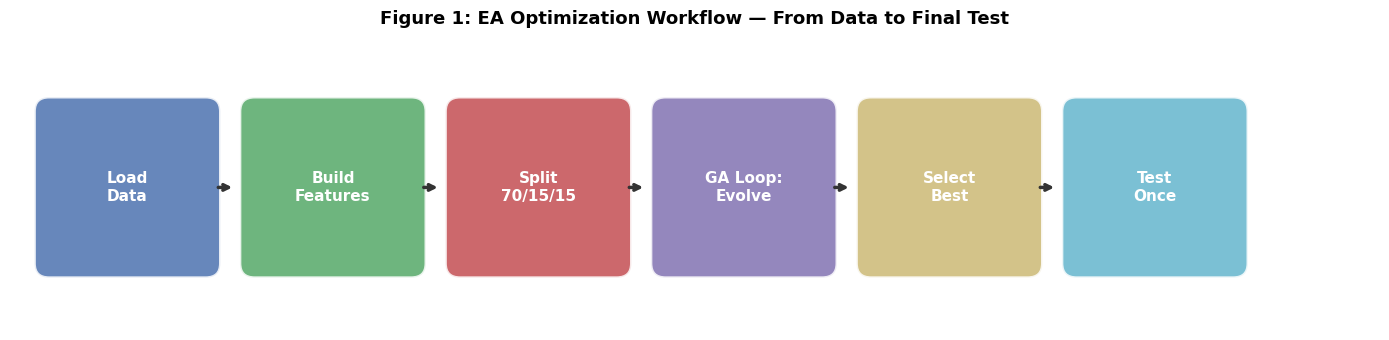

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig1_ea_workflow.png
Caption: This shows the six main steps. The GA loop (purple) is where evolution happens. The test step (blue) happens only once at the end.


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis('off')
fig.patch.set_facecolor('white')

steps = [
    ("Load\nData", "#4C72B0"),
    ("Build\nFeatures", "#55A868"),
    ("Split\n70/15/15", "#C44E52"),
    ("GA Loop:\nEvolve", "#8172B2"),
    ("Select\nBest", "#CCB974"),
    ("Test\nOnce", "#64B5CD"),
]

for i, (label, color) in enumerate(steps):
    x = 1.2 + i * 2.1
    rect = mpatches.FancyBboxPatch((x - 0.8, 0.7), 1.6, 1.6,
                                    boxstyle="round,pad=0.15",
                                    facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, 1.5, label, ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 1.1, 1.5), xytext=(x + 0.9, 1.5),
                     arrowprops=dict(arrowstyle='->', color='#333333', lw=2.5))

ax.set_title("Figure 1: EA Optimization Workflow — From Data to Final Test",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
fig1_path = ARTIFACTS_DIR / "plots" / "fig1_ea_workflow.png"
plt.savefig(fig1_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {fig1_path.resolve()}")
print("Caption: This shows the six main steps. The GA loop (purple) is where evolution happens. The test step (blue) happens only once at the end.")


## Figure 2: Search Space — What One Candidate Contains

Each candidate (also called an **individual** or **chromosome**) represents one possible set of hyperparameter settings for the neural network.

A **chromosome** is simply a list of choices that define how the model is built and trained.

---

### What a candidate contains

Each candidate includes the following hyperparameters:

- **Learning rate** — how fast the model learns  
- **Dropout** — how much randomness is added to prevent overfitting  
- **Layers** — the size and structure of the neural network  
- **Weight decay** — a penalty that helps prevent overly large weights  
- **Batch size** — how many samples are processed at once during training  

---

### Example candidate

One candidate might look like:
- learning_rate = 0.001
- dropout = 0.10
- layers = (256, 128)
- weight_decay = 1e-5
- batch_size = 2048

---

### Why this matters

- Each candidate is one possible “solution” the EA can test  
- The EA evolves these candidates over generations to find better settings  
- This defines the **search space** the algorithm explores

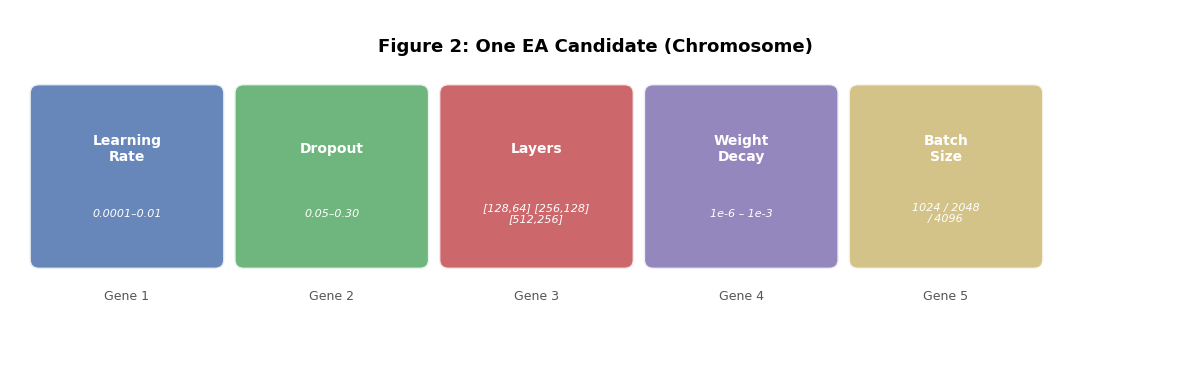

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig2_chromosome.png
Caption: Each candidate is defined by 5 genes. The GA changes these values through crossover and mutation to find the best combination.


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')
fig.patch.set_facecolor('white')

genes = [
    ("Learning\nRate", "0.0001–0.01", "#4C72B0"),
    ("Dropout", "0.05–0.30", "#55A868"),
    ("Layers", "[128,64] [256,128]\n[512,256]", "#C44E52"),
    ("Weight\nDecay", "1e-6 – 1e-3", "#8172B2"),
    ("Batch\nSize", "1024 / 2048\n/ 4096", "#CCB974"),
]

ax.text(6, 3.6, "Figure 2: One EA Candidate (Chromosome)", ha='center', va='center',
        fontsize=13, fontweight='bold')

for i, (name, rng, color) in enumerate(genes):
    x = 1.2 + i * 2.1
    rect = mpatches.FancyBboxPatch((x - 0.9, 1.3), 1.8, 1.8,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, 2.5, name, ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(x, 1.8, rng, ha='center', va='center', fontsize=8, color='white', style='italic')

    # Gene label
    ax.text(x, 0.9, f"Gene {i+1}", ha='center', va='center', fontsize=9, color='#555555')

plt.tight_layout()
fig2_path = ARTIFACTS_DIR / "plots" / "fig2_chromosome.png"
plt.savefig(fig2_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {fig2_path.resolve()}")
print("Caption: Each candidate is defined by 5 genes. The GA changes these values through crossover and mutation to find the best combination.")


## Main EA Optimization Cell

> **What this does:** This is the core of the notebook. It defines the neural network, the fitness function, the GA operators (selection, crossover, mutation), and runs the full evolutionary search.  
> **Why it matters:** This is where all optimization happens. Each candidate is trained on the training set, evaluated on the validation set, and improved over generations.  
> **What it saves:** generation logs (CSV), convergence plots (PNG), best model checkpoint (.pt), final metrics (CSV), environment snapshot (JSON).

---

### How the GA works step by step

1. **Create** a random population of 20 candidates  
2. **Train** each candidate’s neural network using the **training set only**  
3. **Score** each candidate using **validation R² (fitness)**  
4. **Select** the best candidates as parents  
5. **Crossover** two parents to create a child (mix their settings)  
6. **Mutate** some settings randomly (small changes to explore new options)  
7. **Keep** the top 2 candidates unchanged (elitism)  
8. **Repeat** for 15 generations (fixed compute budget)  
9. **Select** the best overall candidate and evaluate it on the **test set exactly once**

---

### Key rules

- Fitness is computed using the **validation set only**  
- The **test set is never used during optimization**  
- The compute budget (population = 20, generations = 15) is fixed  

---

### Key numbers explained

- `EPOCHS_PER_CANDIDATE = 3` → Each candidate trains for 3 epochs to balance speed and learning  
- `PATIENCE = 3` → Stop early if validation does not improve for 3 steps  
- `EVAL_BATCH_SIZE = 65536` → Large batch size for efficient prediction (especially on GPU)  
- `CLIP_MIN_LOG = -2.0`, `CLIP_MAX_LOG = 13.0` → Prevent extreme predictions  
- `TRAIN_IN_LOG_SPACE = True` → Train on log-transformed targets for stability, then convert back for evaluation  


Device: cuda
Artifacts: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2
Saved environment snapshot to: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/environment_snapshot_phase2.json
NRP image hint: gitlab-registry.nrp-nautilus.io/prp/jupyter-stack/prp-pytorch2:v1.0

EA compute budget:
  Population size : 20
  Generations     : 15
  Theoretical eval: 300
  Mutation rate   : 0.1
  Crossover rate  : 0.8
  Elite count     : 2

Smoke test candidate:
{'learning_rate': 0.0035311169138214113, 'dropout': 0.1597196099380131, 'layers': (256, 128), 'weight_decay': 0.00012362436879527074, 'batch_size': 4096}
Validation R²   : 0.003261
Validation MAPE : 36.2965%
Generation 01 | best_val_R2=0.007530 | mean_val_R2=-1.779499 | best_val_MAPE=36.2965% | mean_val_MAPE=90.7091%
Generation 02 | best_val_R2=0.007806 | mean_val_R2=-0.040816 | best_val_MAPE=32.8653% | mean_val_MAPE=40.0370%
Generation 03 | best_val_R2=0.008888 | mean_val_R2=-0.007557 | best_val_MAPE=32.8653% | mean_val_

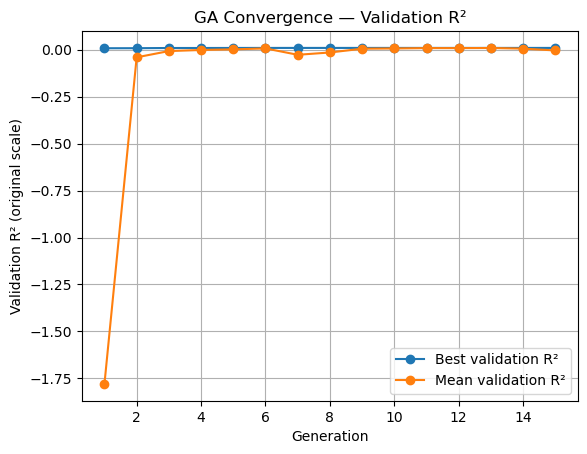

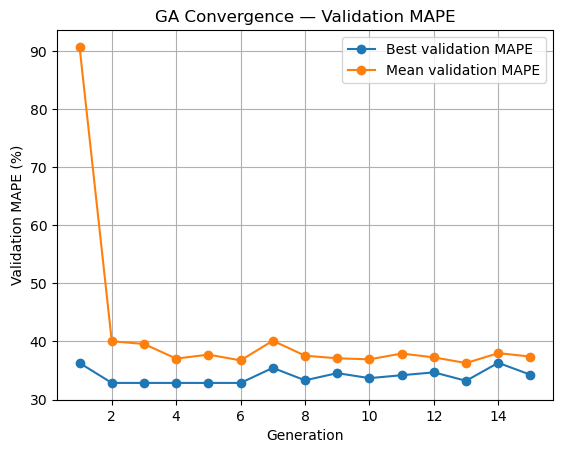

Saved plots:
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/ga_convergence_r2.png
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/ga_convergence_mape.png

=== Final Best Individual ===
{'learning_rate': 0.00461869838886613, 'dropout': 0.16254564919485198, 'layers': (512, 256), 'weight_decay': 0.00019724071684541373, 'batch_size': 1024}

=== Validation Metrics (Best EA Candidate) ===
r2: 0.009057
rmse: 5914.471083
mae: 355.889269
mape: 36.1423%
r2_log: 0.656876
rmse_log: 0.463926
mae_log: 0.313241

=== Test Metrics (Final One-Time Evaluation) ===
r2: -0.233298
rmse: 3381.206067
mae: 337.675847
mape: 36.3187%
r2_log: 0.659848
rmse_log: 0.462181
mae_log: 0.312934

Saved final artifacts:
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/ea_final_metrics.csv
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/best_ea_individual.json
  /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/best_ea_model.pt

=== Compute Summary ==

In [19]:
# ============================================================
# Phase 2 — EA Optimization (GPU-accelerated, compliant version)
# Primary EA fitness: validation R² on ORIGINAL scale
# Secondary tracked metric: validation MAPE on ORIGINAL scale
# Training target: log1p(duration) for stability (fitness/reporting
#                  are still on original scale)
# ============================================================

import os
import sys
import time
import json
import copy
import random
import platform
import subprocess
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# 0) Sanity checks: required objects from earlier cells
# ------------------------------------------------------------
required_names = [
    "SEED", "ARTIFACTS_DIR", "device",
    "X_train_s", "X_val_s", "X_test_s",
    "y_train_orig", "y_val_orig", "y_test_orig",
    "y_train_log", "y_val_log", "y_test_log",
    "log_generation_stats"
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(f"Missing required variables from earlier cells: {missing}")

ARTIFACTS_DIR = Path(ARTIFACTS_DIR)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = ARTIFACTS_DIR / "plots"
LOG_DIR = ARTIFACTS_DIR / "ea_trial_logs"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Artifacts:", ARTIFACTS_DIR.resolve())

# ------------------------------------------------------------
# 1) NRP / environment snapshot (auditable evidence)
# ------------------------------------------------------------
def _safe_cmd(cmd):
    try:
        return subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
    except Exception as e:
        return f"(command failed: {cmd} -> {e})\n"

image_hint = (
    os.environ.get("JUPYTER_IMAGE_SPEC")
    or os.environ.get("CONTAINER_IMAGE")
    or os.environ.get("JUPYTERHUB_IMAGE")
    or os.environ.get("IMAGE_NAME")
    or "UNKNOWN"
)

gpu_count = torch.cuda.device_count() if torch.cuda.is_available() else 0
env_snapshot = {
    "timestamp": pd.Timestamp.now().isoformat(),
    "platform": platform.platform(),
    "python_version": sys.version.replace("\n", " "),
    "python_executable": sys.executable,
    "torch_version": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_version": torch.version.cuda,
    "device": str(device),
    "gpu_count": int(gpu_count),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "nrp_image_hint": image_hint,
}

env_path = ARTIFACTS_DIR / "environment_snapshot_phase2.json"
env_path.write_text(json.dumps(env_snapshot, indent=2), encoding="utf-8")

print("Saved environment snapshot to:", env_path.resolve())
print("NRP image hint:", image_hint)

# ------------------------------------------------------------
# 2) GPU acceleration controls
# ------------------------------------------------------------
USE_CUDA = (torch.cuda.is_available() and str(device).startswith("cuda"))
NUM_GPUS = torch.cuda.device_count() if USE_CUDA else 0
USE_DATA_PARALLEL = NUM_GPUS > 1
USE_AMP = USE_CUDA
PIN_MEMORY = USE_CUDA

# Important notebook fix:
# custom Dataset + Jupyter + multiprocessing workers can crash with:
# "Can't get attribute 'TabularDataset' on <module '__main__'>"
NUM_WORKERS = 0
PERSISTENT_WORKERS = False
PREFETCH_FACTOR = None

EVAL_BATCH_SIZE = 65536 if USE_CUDA else 16384

# ------------------------------------------------------------
# 3) Reproducibility helpers
# ------------------------------------------------------------
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

seed_everything(SEED)

# ------------------------------------------------------------
# 4) Metrics + target handling
# ------------------------------------------------------------
TRAIN_IN_LOG_SPACE = True
CLIP_MIN_LOG = -2.0
CLIP_MAX_LOG = 13.0

def safe_expm1(yhat_log, clip_min=CLIP_MIN_LOG, clip_max=CLIP_MAX_LOG):
    yhat_log = np.asarray(yhat_log).reshape(-1)
    yhat_log = np.clip(yhat_log, clip_min, clip_max)
    return np.expm1(yhat_log)

def mape(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics_original(y_true_orig, y_pred_orig):
    return {
        "r2": float(r2_score(y_true_orig, y_pred_orig)),
        "rmse": float(mean_squared_error(y_true_orig, y_pred_orig, squared=False)),
        "mae": float(mean_absolute_error(y_true_orig, y_pred_orig)),
        "mape": float(mape(y_true_orig, y_pred_orig)),
    }

def regression_metrics_log(y_true_log, y_pred_log):
    return {
        "r2_log": float(r2_score(y_true_log, y_pred_log)),
        "rmse_log": float(mean_squared_error(y_true_log, y_pred_log, squared=False)),
        "mae_log": float(mean_absolute_error(y_true_log, y_pred_log)),
    }

def autocast_context():
    if USE_AMP:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

# ------------------------------------------------------------
# 5) Data interface
# ------------------------------------------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(np.asarray(X), dtype=torch.float32)
        self.y = torch.as_tensor(np.asarray(y), dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

X_train_np = np.asarray(X_train_s, dtype=np.float32)
X_val_np   = np.asarray(X_val_s, dtype=np.float32)
X_test_np  = np.asarray(X_test_s, dtype=np.float32)

# Training target can be log-space, but fitness/reporting remain original-scale.
y_train_fit = y_train_log if TRAIN_IN_LOG_SPACE else y_train_orig
y_val_fit   = y_val_log if TRAIN_IN_LOG_SPACE else y_val_orig
y_test_fit  = y_test_log if TRAIN_IN_LOG_SPACE else y_test_orig

# Build shared datasets/tensors once to reduce repeated setup cost.
train_ds = TabularDataset(X_train_np, y_train_fit)
X_val_tensor = torch.as_tensor(X_val_np, dtype=torch.float32, device=device)
X_test_tensor = torch.as_tensor(X_test_np, dtype=torch.float32, device=device)

def make_train_loader(batch_size, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    kwargs = dict(
        dataset=train_ds,
        batch_size=int(batch_size),
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        generator=generator,
    )
    if PREFETCH_FACTOR is not None:
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(**kwargs)

# ------------------------------------------------------------
# 6) Model / individual encoding
# ------------------------------------------------------------
SEARCH_SPACE = {
    "learning_rate": (1e-4, 1e-2),                   # continuous (log-uniform)
    "dropout": (0.05, 0.30),                         # continuous
    "layers": [(128, 64), (256, 128), (512, 256)],  # discrete
    "weight_decay": (1e-6, 1e-3),                   # continuous (log-uniform)
    "batch_size": [1024, 2048, 4096] if USE_CUDA else [1024, 2048],
}

POPULATION_SIZE = 20
GENERATIONS = 15
MUTATION_RATE = 0.10
CROSSOVER_RATE = 0.80
ELITE_COUNT = 2

# Fixed internal training budget per candidate
EPOCHS_PER_CANDIDATE = 3
PATIENCE = 3

print("\nEA compute budget:")
print("  Population size :", POPULATION_SIZE)
print("  Generations     :", GENERATIONS)
print("  Theoretical eval:", POPULATION_SIZE * GENERATIONS)
print("  Mutation rate   :", MUTATION_RATE)
print("  Crossover rate  :", CROSSOVER_RATE)
print("  Elite count     :", ELITE_COUNT)

def sample_log_uniform(low, high, rng):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))

def create_individual(rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    return {
        "learning_rate": sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng=rng),
        "dropout": float(rng.uniform(*SEARCH_SPACE["dropout"])),
        "layers": tuple(SEARCH_SPACE["layers"][int(rng.integers(0, len(SEARCH_SPACE["layers"])))]),
        "weight_decay": sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng=rng),
        "batch_size": int(SEARCH_SPACE["batch_size"][int(rng.integers(0, len(SEARCH_SPACE["batch_size"])))]),
    }

def individual_key(ind):
    return (
        round(float(ind["learning_rate"]), 10),
        round(float(ind["dropout"]), 10),
        tuple(ind["layers"]),
        round(float(ind["weight_decay"]), 10),
        int(ind["batch_size"]),
    )

def unwrap_model(model):
    return model.module if hasattr(model, "module") else model

def build_model_from_individual(individual, in_dim):
    layers = individual["layers"]
    dropout = float(individual["dropout"])
    net = []
    prev = in_dim
    for h in layers:
        net.append(nn.Linear(prev, h))
        net.append(nn.ReLU())
        net.append(nn.Dropout(dropout))
        prev = h
    net.append(nn.Linear(prev, 1))
    base_model = nn.Sequential(*net).to(device)

    if USE_DATA_PARALLEL:
        base_model = nn.DataParallel(base_model)
    return base_model

# ------------------------------------------------------------
# 7) Prediction helpers (batched on-device inference)
# ------------------------------------------------------------
def model_predict_fit_space(model, X_tensor):
    model.eval()
    preds = []
    with torch.inference_mode():
        with autocast_context():
            for start in range(0, X_tensor.shape[0], EVAL_BATCH_SIZE):
                xb = X_tensor[start:start + EVAL_BATCH_SIZE]
                out = model(xb).view(-1)
                preds.append(out.detach().float().cpu())
    preds = torch.cat(preds).numpy().reshape(-1)
    if TRAIN_IN_LOG_SPACE:
        preds = np.clip(preds, CLIP_MIN_LOG, CLIP_MAX_LOG)
    return preds

def fit_to_original_scale(pred_fit):
    if TRAIN_IN_LOG_SPACE:
        return safe_expm1(pred_fit)
    return np.maximum(pred_fit, 0.0)

def model_predict_original(model, X_tensor):
    pred_fit = model_predict_fit_space(model, X_tensor)
    return fit_to_original_scale(pred_fit)
# ------------------------------------------------------------
# 8) Train/evaluate one candidate
# ------------------------------------------------------------
def evaluate_candidate(individual, trial_seed):
    """
    Train on TRAIN only.
    Select epoch by VALIDATION R² on ORIGINAL scale.
    Return both primary metric (val_r2) and secondary metric (val_mape).
    """
    seed_everything(trial_seed)

    model = build_model_from_individual(individual, in_dim=X_train_np.shape[1])
    train_loader = make_train_loader(batch_size=individual["batch_size"], seed=trial_seed)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(individual["learning_rate"]),
        weight_decay=float(individual["weight_decay"]),
    )
    loss_fn = nn.SmoothL1Loss(beta=0.5) if TRAIN_IN_LOG_SPACE else nn.MSELoss()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_state = None
    best_epoch = 0
    best_val_r2 = -np.inf
    best_epoch_metrics = None
    patience_counter = 0
    history = []

    for epoch in range(1, EPOCHS_PER_CANDIDATE + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=PIN_MEMORY)
            yb = yb.to(device, non_blocking=PIN_MEMORY).view(-1)

            optimizer.zero_grad(set_to_none=True)
            with autocast_context():
                preds = model(xb).view(-1)
                if TRAIN_IN_LOG_SPACE:
                    preds = torch.clamp(preds, CLIP_MIN_LOG, CLIP_MAX_LOG)
                loss = loss_fn(preds, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += float(loss.detach().item()) * xb.size(0)
            seen += xb.size(0)

        train_loss = running_loss / max(seen, 1)

        # Single validation pass, then score in both spaces
        val_pred_fit = model_predict_fit_space(model, X_val_tensor)
        val_pred_orig = fit_to_original_scale(val_pred_fit)

        val_metrics_orig = regression_metrics_original(y_val_orig, val_pred_orig)
        val_metrics_log = regression_metrics_log(y_val_fit, val_pred_fit)

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            **{f"val_{k}": v for k, v in val_metrics_orig.items()},
            **{f"val_{k}": v for k, v in val_metrics_log.items()},
        }
        history.append(row)

        # Early stopping within candidate training: based on PRIMARY metric (val_r2)
        if val_metrics_orig["r2"] > best_val_r2 + 1e-6:
            best_val_r2 = val_metrics_orig["r2"]
            best_epoch = epoch
            best_epoch_metrics = {
                **val_metrics_orig,
                **val_metrics_log,
            }
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in unwrap_model(model).state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    if best_state is None:
        raise RuntimeError("No valid state captured during candidate evaluation.")
    unwrap_model(model).load_state_dict(best_state)

    hist_path = LOG_DIR / f"candidate_{abs(hash(individual_key(individual))) % 10**10}_{trial_seed}.csv"
    pd.DataFrame(history).to_csv(hist_path, index=False)

    result = {
        "model": model,
        "best_epoch": int(best_epoch),
        "history_csv": str(hist_path),
        "val_r2": float(best_epoch_metrics["r2"]),
        "val_rmse": float(best_epoch_metrics["rmse"]),
        "val_mae": float(best_epoch_metrics["mae"]),
        "val_mape": float(best_epoch_metrics["mape"]),
        "val_r2_log": float(best_epoch_metrics["r2_log"]),
        "val_rmse_log": float(best_epoch_metrics["rmse_log"]),
        "val_mae_log": float(best_epoch_metrics["mae_log"]),
    }
    return result

# ------------------------------------------------------------
# 9) GA operators
# ------------------------------------------------------------
def initialize_population(size, seed=SEED):
    rng = np.random.default_rng(seed)
    return [create_individual(rng) for _ in range(size)]

def tournament_selection(population, metrics_list, k=3, seed=None):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(population), size=k, replace=False)
    best_idx = max(idxs, key=lambda i: metrics_list[i]["val_r2"])  # maximize validation R²
    return copy.deepcopy(population[best_idx])

def crossover(parent1, parent2, seed=None):
    rng = np.random.default_rng(seed)
    child = {}
    for key in parent1.keys():
        child[key] = copy.deepcopy(parent1[key] if rng.random() < 0.5 else parent2[key])
    return child

def mutate(individual, mutation_rate=MUTATION_RATE, seed=None):
    rng = np.random.default_rng(seed)
    child = copy.deepcopy(individual)

    if rng.random() < mutation_rate:
        child["learning_rate"] = sample_log_uniform(*SEARCH_SPACE["learning_rate"], rng=rng)

    if rng.random() < mutation_rate:
        child["dropout"] = float(rng.uniform(*SEARCH_SPACE["dropout"]))

    if rng.random() < mutation_rate:
        child["layers"] = tuple(SEARCH_SPACE["layers"][int(rng.integers(0, len(SEARCH_SPACE["layers"])))])

    if rng.random() < mutation_rate:
        child["weight_decay"] = sample_log_uniform(*SEARCH_SPACE["weight_decay"], rng=rng)

    if rng.random() < mutation_rate:
        child["batch_size"] = int(SEARCH_SPACE["batch_size"][int(rng.integers(0, len(SEARCH_SPACE["batch_size"])))])

    return child

# ------------------------------------------------------------
# 10) Fitness cache + fitness function
# ------------------------------------------------------------
fitness_cache = {}
fitness_calls = 0

def fitness(individual, eval_id):
    """
    Authoritative EA fitness.
    Returns PRIMARY metric only: validation R² on ORIGINAL scale.
    Secondary metric (validation MAPE) is also computed and cached.
    """
    global fitness_calls

    key = individual_key(individual)
    if key not in fitness_cache:
        fitness_calls += 1
        result = evaluate_candidate(individual, trial_seed=SEED + eval_id)
        fitness_cache[key] = {
            "val_r2": result["val_r2"],
            "val_mape": result["val_mape"],
            "best_epoch": result["best_epoch"],
        }

    return fitness_cache[key]["val_r2"]

# ------------------------------------------------------------
# 11) Smoke test
# ------------------------------------------------------------
def get_cached_metrics(individual):
    key = individual_key(individual)
    if key not in fitness_cache:
        raise ValueError("Individual not found in fitness_cache")
    return fitness_cache[key]



_smoke_individual = create_individual(np.random.default_rng(SEED))
_ = fitness(_smoke_individual, eval_id=1)
_smoke_metrics = get_cached_metrics(_smoke_individual)

print("\nSmoke test candidate:")
print(_smoke_individual)
print(f"Validation R²   : {_smoke_metrics['val_r2']:.6f}")
print(f"Validation MAPE : {_smoke_metrics['val_mape']:.4f}%")

# ------------------------------------------------------------
# 12) Main GA loop
# ------------------------------------------------------------
seed_everything(SEED)
generation_logs = []   # reset in case cell is rerun
ga_start = time.time()

population = initialize_population(POPULATION_SIZE, seed=SEED)
best_individual = None
best_metrics = None
all_generation_summaries = []
eval_counter = 1  # deterministic per-fitness call seeding offset

for g in range(1, GENERATIONS + 1):
    population_metrics = []
    for ind in population:
        _ = fitness(ind, eval_id=eval_counter)
        metrics = get_cached_metrics(ind)
        population_metrics.append(metrics)
        eval_counter += 1

    gen_row = log_generation_stats(generation=g, population_metrics=population_metrics)
    all_generation_summaries.append(gen_row)

    best_idx = int(np.argmax([m["val_r2"] for m in population_metrics]))
    current_best_ind = population[best_idx]
    current_best_metrics = population_metrics[best_idx]

    if (best_metrics is None) or (current_best_metrics["val_r2"] > best_metrics["val_r2"]):
        best_individual = copy.deepcopy(current_best_ind)
        best_metrics = dict(current_best_metrics)

    print(
        f"Generation {g:02d} | "
        f"best_val_R2={gen_row['best_val_r2']:.6f} | "
        f"mean_val_R2={gen_row['mean_val_r2']:.6f} | "
        f"best_val_MAPE={gen_row['best_val_mape']:.4f}% | "
        f"mean_val_MAPE={gen_row['mean_val_mape']:.4f}%"
    )

    ranked = np.argsort([-m["val_r2"] for m in population_metrics])  # descending by val_r2
    next_population = [copy.deepcopy(population[i]) for i in ranked[:ELITE_COUNT]]

    while len(next_population) < POPULATION_SIZE:
        p1 = tournament_selection(population, population_metrics, k=3, seed=SEED + g * 100 + len(next_population))
        p2 = tournament_selection(population, population_metrics, k=3, seed=SEED + g * 1000 + len(next_population))

        if np.random.rand() < CROSSOVER_RATE:
            child = crossover(p1, p2, seed=SEED + g * 10 + len(next_population))
        else:
            child = copy.deepcopy(p1)

        child = mutate(child, mutation_rate=MUTATION_RATE, seed=SEED + g * 10000 + len(next_population))
        next_population.append(child)

    population = next_population[:POPULATION_SIZE]

ga_end = time.time()
total_runtime_sec = ga_end - ga_start

# ------------------------------------------------------------
# 13) Save generation logs
# ------------------------------------------------------------
generation_logs_df = pd.DataFrame(generation_logs)
gen_logs_path = ARTIFACTS_DIR / "generation_logs.csv"
generation_logs_df.to_csv(gen_logs_path, index=False)
print("\nSaved generation logs to:", gen_logs_path.resolve())

# ------------------------------------------------------------
# 14) Convergence plots (R² + MAPE)
# ------------------------------------------------------------
plt.figure()
plt.plot(generation_logs_df["generation"], generation_logs_df["best_val_r2"], marker="o", label="Best validation R²")
plt.plot(generation_logs_df["generation"], generation_logs_df["mean_val_r2"], marker="o", label="Mean validation R²")
plt.xlabel("Generation")
plt.ylabel("Validation R² (original scale)")
plt.title("GA Convergence — Validation R²")
plt.grid(True)
plt.legend()
r2_plot_path = PLOTS_DIR / "ga_convergence_r2.png"
plt.savefig(r2_plot_path, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(generation_logs_df["generation"], generation_logs_df["best_val_mape"], marker="o", label="Best validation MAPE")
plt.plot(generation_logs_df["generation"], generation_logs_df["mean_val_mape"], marker="o", label="Mean validation MAPE")
plt.xlabel("Generation")
plt.ylabel("Validation MAPE (%)")
plt.title("GA Convergence — Validation MAPE")
plt.grid(True)
plt.legend()
mape_plot_path = PLOTS_DIR / "ga_convergence_mape.png"
plt.savefig(mape_plot_path, bbox_inches="tight")
plt.show()

print("Saved plots:")
print(" ", r2_plot_path.resolve())
print(" ", mape_plot_path.resolve())

# ------------------------------------------------------------
# 15) Final selected model (validation-only selection already done)
# ------------------------------------------------------------
final_result = evaluate_candidate(best_individual, trial_seed=SEED + 999999)
best_model = final_result["model"]

val_pred_fit = model_predict_fit_space(best_model, X_val_tensor)
val_pred_orig = fit_to_original_scale(val_pred_fit)
final_val_metrics = {
    **regression_metrics_original(y_val_orig, val_pred_orig),
    **regression_metrics_log(y_val_fit, val_pred_fit),
}

test_pred_fit = model_predict_fit_space(best_model, X_test_tensor)
test_pred_orig = fit_to_original_scale(test_pred_fit)
final_test_metrics = {
    **regression_metrics_original(y_test_orig, test_pred_orig),
    **regression_metrics_log(y_test_fit, test_pred_fit),
}

print("\n=== Final Best Individual ===")
print(best_individual)

print("\n=== Validation Metrics (Best EA Candidate) ===")
for k, v in final_val_metrics.items():
    if "mape" in k:
        print(f"{k}: {v:.4f}%")
    else:
        print(f"{k}: {v:.6f}")

print("\n=== Test Metrics (Final One-Time Evaluation) ===")
for k, v in final_test_metrics.items():
    if "mape" in k:
        print(f"{k}: {v:.4f}%")
    else:
        print(f"{k}: {v:.6f}")

# ------------------------------------------------------------
# 16) Save final artifacts
# ------------------------------------------------------------
final_summary = pd.DataFrame([
    {"split": "validation", **final_val_metrics},
    {"split": "test", **final_test_metrics},
])
final_summary_path = ARTIFACTS_DIR / "ea_final_metrics.csv"
final_summary.to_csv(final_summary_path, index=False)

best_individual_path = ARTIFACTS_DIR / "best_ea_individual.json"
with open(best_individual_path, "w", encoding="utf-8") as f:
    json.dump(best_individual, f, indent=2)

best_model_ckpt = {
    "model_state_dict": {
        k: v.detach().cpu()
        for k, v in unwrap_model(best_model).state_dict().items()
    },
    "best_individual": best_individual,
    "train_in_log_space": TRAIN_IN_LOG_SPACE,
    "clip_min_log": CLIP_MIN_LOG,
    "clip_max_log": CLIP_MAX_LOG,
    "seed": SEED,
    "use_data_parallel": USE_DATA_PARALLEL,
}
best_model_path = ARTIFACTS_DIR / "best_ea_model.pt"
torch.save(best_model_ckpt, best_model_path)

print("\nSaved final artifacts:")
print(" ", final_summary_path.resolve())
print(" ", best_individual_path.resolve())
print(" ", best_model_path.resolve())

# ------------------------------------------------------------
# 17) Compute-budget summary
# ------------------------------------------------------------
theoretical_evals = POPULATION_SIZE * GENERATIONS
actual_unique_evals = fitness_calls

print("\n=== Compute Summary ===")
print("Population size           :", POPULATION_SIZE)
print("Generations               :", GENERATIONS)
print("Theoretical evaluations   :", theoretical_evals)
print("Actual unique evaluations :", actual_unique_evals)
print("Total runtime (seconds)   :", round(total_runtime_sec, 2))
print("Total runtime (minutes)   :", round(total_runtime_sec / 60.0, 2))
print("Device used               :", device)
print("GPU count                 :", NUM_GPUS)
print("Environment snapshot      :", env_path.name)

# ------------------------------------------------------------
# 18) Completion message
# ------------------------------------------------------------
print("\nPhase 2 Step 2 COMPLETE — EA optimization executed successfully.")
print("Primary optimization metric: validation R² (original scale)")
print("Secondary tracked metric: validation MAPE (original scale)")
print("GPU-aware acceleration enabled: AMP, batched on-device inference, pinned-memory loaders.")
if USE_DATA_PARALLEL:
    print("Multi-GPU DataParallel active.")


### Figure 3: GA Convergence — Validation R²

The plot above (saved as `ga_convergence_r2.png`) shows how the best and average **validation R²** change across generations (fixed at 15 generations).

---

### How to read it

- The **blue line (best)** shows the highest validation R² found in each generation  
- The **orange line (mean)** shows the average performance of all candidates in the population  

---

### What to look for

- The best line should generally **increase over time**, meaning the EA is finding better solutions  
- The mean line may also increase, showing overall population improvement  
- If both lines flatten out, the EA has **converged** (stopped improving)  
- If the lines do not improve, the search space or budget may be too limited  

👉 **Higher is better** for R²  

---

### Important note

- All values are computed using the **validation set only**  
- The test set is not used in these plots  

---

### Figure 4: GA Convergence — Validation MAPE

The second plot (saved as `ga_convergence_mape.png`) shows how validation **MAPE** changes across generations.

---

### How to read it

- The **blue line (best)** shows the lowest validation MAPE in each generation  
- The **orange line (mean)** shows the average error across the population  

---

### What to look for

- The best line should generally **decrease over time**, meaning predictions are becoming more accurate  
- The mean line may also decrease as the population improves  
- If both lines flatten out, the EA has **converged**  

👉 **Lower is better** for MAPE  

---

### Important note

- All values are computed using the **validation set only**  
- The test set is not used in these plots  


---
## Phase 2 — Step 3.1: Load Phase 1 Neural Network Reference

> **What this does:** Loads the predictions from the Phase 1 neural network so we can compare them against the EA-optimized model.  
> **Why it matters:** The goal of Phase 2 is to determine whether the EA improves performance. To make a fair comparison, both models must be evaluated on the exact same test data.

---

### What we load

- A CSV file containing:
  - **True trip durations** (`y_true`)  
  - **Phase 1 NN predictions** (`y_pred_phase1`)  
- All values are on the original scale (seconds)

---

### Important rules (no leakage)

- These values come from the **final holdout test set**, which was never used during training or tuning  
- The same test set is used for both Phase 1 and Phase 2 models  
- This ensures a **paired and fair comparison** between models


In [20]:
# ============================================================
# Load Phase 1 NN predictions from the shared artifacts folder
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PHASE1_PRED_PATH = Path("../artifacts/phase1_nn_test_predictions.csv")
assert PHASE1_PRED_PATH.exists(), f"Missing file: {PHASE1_PRED_PATH.resolve()}"

phase1_df = pd.read_csv(PHASE1_PRED_PATH)

phase1_y_test_orig = phase1_df["y_true"].to_numpy().astype(np.float64)
nn_test_pred_orig = phase1_df["nn_pred"].to_numpy().astype(np.float64)

print("Loaded Phase 1 predictions from:", PHASE1_PRED_PATH.resolve())
print("Rows:", len(phase1_df))
display(phase1_df.head())

Loaded Phase 1 predictions from: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase1_nn_test_predictions.csv
Rows: 150000


,y_true,nn_pred
0,893.0,784.51980
1,387.0,235.01308
2,2491.0,1567.52590
3,947.0,998.66254
4,704.0,752.82860


### Compute Phase 1 NN Metrics

> **What this does:** Calculates R², RMSE, MAE, and MAPE for the Phase 1 neural network predictions on the test set.  
> **Why it matters:** These metrics serve as the reference baseline for comparison with the EA-optimized model.

---

### Important details

- Metrics are computed using the **same holdout test set** used for the EA model  
- This ensures a **fair, side-by-side comparison**  
- The test set is used **only once** for final evaluation (no tuning)

---

### What the metrics represent

- **R²** → how well the model explains the data (higher is better)  
- **RMSE / MAE** → size of prediction errors in seconds  
- **MAPE** → average percent error (useful for comparing across models)

Using multiple metrics gives a more complete view of model performance.

In [21]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def mape(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true).reshape(-1).astype(np.float64)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.float64)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

phase1_nn_metrics = {
    "r2": float(r2_score(phase1_y_test_orig, nn_test_pred_orig)),
    "rmse": float(mean_squared_error(phase1_y_test_orig, nn_test_pred_orig, squared=False)),
    "mae": float(mean_absolute_error(phase1_y_test_orig, nn_test_pred_orig)),
    "mape": float(mape(phase1_y_test_orig, nn_test_pred_orig)),
}

print("Phase 1 NN metrics:")
print(phase1_nn_metrics)

Phase 1 NN metrics:
{'r2': -0.1606901954679134, 'rmse': 3280.165841465935, 'mae': 320.0547231257, 'mape': 32.51302294434897}


## Sanity Check — Same Test Set Verification

> **What this does:** Confirms that the Phase 1 NN and the EA model were evaluated on the **exact same test trips**, in the same order.  
> **Why it matters:** Our statistical comparison is **paired**, meaning each EA prediction is compared to the NN prediction for the same trip. If the test sets do not match exactly, the comparison is invalid.

---

### What is verified

- Both models use the same **holdout test set**  
- Rows are in the same order  
- No reshuffling or filtering has occurred  

---

### Why this is important

- Ensures a **fair, one-to-one comparison** between models  
- Required for valid statistical testing (e.g., bootstrap or paired analysis)  
- Prevents incorrect conclusions due to mismatched data


In [22]:
ea_y_test_orig = np.asarray(y_test_orig).reshape(-1).astype(np.float64)
ea_test_pred_orig = np.asarray(test_pred_orig).reshape(-1).astype(np.float64)

assert len(phase1_y_test_orig) == len(ea_y_test_orig), "Phase 1 and EA test lengths do not match."
assert len(nn_test_pred_orig) == len(ea_test_pred_orig), "Prediction lengths do not match."

same_targets = np.allclose(phase1_y_test_orig, ea_y_test_orig)
print("Do Phase 1 and EA use the same test targets?", same_targets)

if not same_targets:
    raise ValueError("Test targets do not match. Paired comparison is invalid until the same Phase 1 split is reused.")

Do Phase 1 and EA use the same test targets? True


## Phase 2 — Step 3.1: Final Model Comparison

> **What this does:** Creates a side-by-side comparison table of the Phase 1 NN and the EA-optimized NN using the holdout test set.  
> **Why it matters:** This is the main result of the project — it shows whether the Evolutionary Algorithm actually improved model performance.

---

### Important rules

- All metrics are computed on the **same holdout test set**  
- The test set is used **only once** for final evaluation  
- This ensures a **fair and unbiased comparison**

---

### Metrics reported

- **R²** → how well the model explains variation (higher is better)  
- **MAPE** → average percentage error (lower is better)  
- **RMSE** → prediction error in seconds (lower is better)  
- **MAE** → average error in seconds (lower is better)  

👉 **R² and MAPE are the primary metrics** for comparison.

---

### Deltas (improvement over Phase 1)

- **ΔR² = EA − Phase 1 NN** → positive means EA performs better  
- **ΔMAPE = EA − Phase 1 NN** → negative means EA has lower error  

---

### How to interpret results

- If ΔR² is positive and ΔMAPE is negative, the EA improved the model  
- Small changes may not be meaningful, so statistical validation is needed  


In [23]:
# ============================================================
# Final comparison table: Phase 1 NN vs EA-Optimized NN
# ============================================================

ea_metrics = {
    "r2": float(final_test_metrics["r2"]),
    "rmse": float(final_test_metrics["rmse"]),
    "mae": float(final_test_metrics["mae"]),
    "mape": float(final_test_metrics["mape"]),
}

phase1_nn_runtime_sec = None   # fill in if you tracked it in Phase 1
phase1_nn_evaluations = 20     # replace if you have the exact count
ea_runtime_sec = float(total_runtime_sec)
ea_evaluations = float(TOTAL_EVALUATIONS)

comparison_df = pd.DataFrame([
    {
        "Model": "Phase 1 NN",
        "R2": phase1_nn_metrics["r2"],
        "MAPE": phase1_nn_metrics["mape"],
        "RMSE": phase1_nn_metrics["rmse"],
        "MAE": phase1_nn_metrics["mae"],
        "Runtime_sec": phase1_nn_runtime_sec,
        "Evaluations": phase1_nn_evaluations,
    },
    {
        "Model": "EA-Optimized NN",
        "R2": ea_metrics["r2"],
        "MAPE": ea_metrics["mape"],
        "RMSE": ea_metrics["rmse"],
        "MAE": ea_metrics["mae"],
        "Runtime_sec": ea_runtime_sec,
        "Evaluations": ea_evaluations,
    },
])

delta_r2 = ea_metrics["r2"] - phase1_nn_metrics["r2"]
delta_mape = ea_metrics["mape"] - phase1_nn_metrics["mape"]   # negative = better
delta_rmse = ea_metrics["rmse"] - phase1_nn_metrics["rmse"]   # negative = better
delta_mae = ea_metrics["mae"] - phase1_nn_metrics["mae"]      # negative = better

runtime_increase_sec = None if phase1_nn_runtime_sec is None else ea_runtime_sec - phase1_nn_runtime_sec
evaluation_increase = None if phase1_nn_evaluations is None else ea_evaluations - phase1_nn_evaluations

delta_df = pd.DataFrame([{
    "Delta_R2__EA_minus_Phase1NN": delta_r2,
    "Delta_MAPE__EA_minus_Phase1NN": delta_mape,
    "Delta_RMSE__EA_minus_Phase1NN": delta_rmse,
    "Delta_MAE__EA_minus_Phase1NN": delta_mae,
    "Runtime_Increase_sec": runtime_increase_sec,
    "Evaluation_Increase": evaluation_increase,
}])

display(comparison_df)
display(delta_df)

comparison_df.to_csv(ARTIFACTS_DIR / "phase2_final_comparison_table.csv", index=False)
delta_df.to_csv(ARTIFACTS_DIR / "phase2_final_deltas.csv", index=False)

print("Interpretation:")
print(f"ΔR²   = {delta_r2:+.6f}  -> {'EA improved R²' if delta_r2 > 0 else 'EA did not improve R²'}")
print(f"ΔMAPE = {delta_mape:+.4f}% -> {'EA improved MAPE' if delta_mape < 0 else 'EA did not improve MAPE'}")

,Model,R2,MAPE,RMSE,MAE,Runtime_sec,Evaluations
0,Phase 1 NN,-0.160690,32.513023,3280.165841,320.054723,NaN,20.0
1,EA-Optimized NN,-0.233298,36.318662,3381.206067,337.675847,1999.041225,300.0


,Delta_R2__EA_minus_Phase1NN,Delta_MAPE__EA_minus_Phase1NN,Delta_RMSE__EA_minus_Phase1NN,Delta_MAE__EA_minus_Phase1NN,Runtime_Increase_sec,Evaluation_Increase
0,-0.072608,3.805639,101.040226,17.621123,None,280.0


Interpretation:
ΔR²   = -0.072608  -> EA did not improve R²
ΔMAPE = +3.8056% -> EA did not improve MAPE


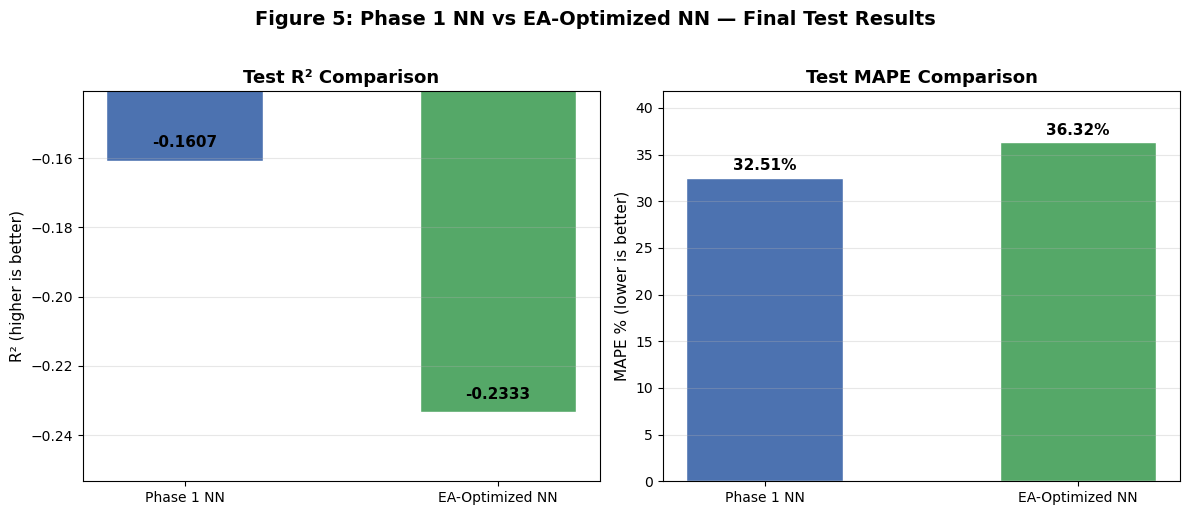

Saved: /home/jovyan/csusb_spring26_cse5140_team1/artifacts/phase2/plots/fig5_final_comparison.png
Caption: Blue = Phase 1 NN baseline. Green = EA-Optimized NN. Left chart: higher R² is better. Right chart: lower MAPE is better.


In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── R² comparison ──
models = ['Phase 1 NN', 'EA-Optimized NN']
r2_vals = [phase1_nn_metrics['r2'], ea_metrics['r2']]
colors_r2 = ['#4C72B0', '#55A868']

axes[0].bar(models, r2_vals, color=colors_r2, edgecolor='white', width=0.5)
axes[0].set_ylabel('R² (higher is better)', fontsize=11)
axes[0].set_title('Test R² Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(min(r2_vals) - 0.02, max(r2_vals) + 0.02)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# ── MAPE comparison ──
mape_vals = [phase1_nn_metrics['mape'], ea_metrics['mape']]
colors_mape = ['#4C72B0', '#55A868']

axes[1].bar(models, mape_vals, color=colors_mape, edgecolor='white', width=0.5)
axes[1].set_ylabel('MAPE % (lower is better)', fontsize=11)
axes[1].set_title('Test MAPE Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(mape_vals) * 1.15)
for i, v in enumerate(mape_vals):
    axes[1].text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Figure 5: Phase 1 NN vs EA-Optimized NN — Final Test Results",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

fig5_path = ARTIFACTS_DIR / "plots" / "fig5_final_comparison.png"
plt.savefig(fig5_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {fig5_path.resolve()}")
print("Caption: Blue = Phase 1 NN baseline. Green = EA-Optimized NN. Left chart: higher R² is better. Right chart: lower MAPE is better.")


## Figure 5: Final Comparison — Baseline NN vs EA-Optimized NN

This bar chart compares the performance of two models on the **same held-out test set** that was never used during training or optimization:

- **Phase 1 NN** — the best neural network from Phase 1, selected using validation-only tuning
- **EA-Optimized NN** — the neural network whose hyperparameters were found by the Evolutionary Algorithm in Phase 2

---

### How to read the chart

**Left panel — R² (R-squared):**
- R² measures how well the model's predictions explain the variation in actual trip durations
- A value of **1.0** would mean perfect predictions
- A value of **0.0** means the model is no better than just guessing the average trip duration
- **Negative values** mean the model's predictions are worse than just guessing the average — this can happen when trip durations are extremely skewed (most trips are short, but some are very long)
- **Higher R² = better**

**Right panel — MAPE (Mean Absolute Percentage Error):**
- MAPE measures the average percentage by which the model's predictions are off from the actual trip duration
- For example, a MAPE of 35% means predictions are off by about 35% on average
- **Lower MAPE = better**

---

### What to look for

- Compare the bar heights between the two models
- For R²: the taller (or less negative) bar is the better model
- For MAPE: the shorter bar is the better model
- The exact values are printed in the comparison table above this chart

---

### Why this matters

This comparison directly answers **Research Question 3**: *Can evolutionary algorithms improve neural network performance through hyperparameter optimization?*

The chart shows whether the EA's automated search found hyperparameters that produce better predictions than the manually-tuned Phase 1 model. The statistical validation in the next section tests whether any observed difference is real or could be due to random chance.

---
## Phase 2 — Step 3.2: Statistical Validation (Bootstrap Confidence Intervals)

> **What this does:** Tests whether the difference between the EA model and the Phase 1 NN is real or just due to random variation.  
> **Why it matters:** A single test score can vary by chance. By resampling the test set many times, we estimate how stable the difference between models is.

---

### How it works (plain language)

1. Randomly sample test trips **with replacement** (like drawing names from a hat and putting them back)  
2. Compute R² and MAPE for both models on that sample  
3. Calculate the difference (**EA − Phase 1 NN**)  
4. Repeat 1,000 times to build a distribution of differences  
5. Compute the **95% confidence interval** (from the 2.5th to 97.5th percentile)

---

### Important note

- This is a **paired comparison**, meaning both models are evaluated on the **same test samples** each time  
- The test set is never used for training or tuning  

---

### How to interpret results

- If **zero is NOT inside the interval** → the difference is statistically supported (likely real)  
- If **zero IS inside the interval** → the difference may be due to random variation  

---

### Direction of the result

- If ΔR² > 0 → EA performs better  
- If ΔR² < 0 → EA performs worse  
- If ΔMAPE < 0 → EA has lower error (better)  
- If ΔMAPE > 0 → EA has higher error (worse)  

---

> **Simple version:** “This checks whether the difference between models is real, not just luck.”


In [25]:
# ============================================================
# Paired bootstrap CI for ΔR² and ΔMAPE
# This checks whether the improvement is probably real, not just luck.
# ============================================================

N_BOOTSTRAP = 1000
rng = np.random.RandomState(SEED)

y_true = ea_y_test_orig
nn_pred = np.asarray(nn_test_pred_orig).reshape(-1).astype(np.float64)
ea_pred = np.asarray(ea_test_pred_orig).reshape(-1).astype(np.float64)

n = len(y_true)

delta_r2_samples = []
delta_mape_samples = []

for _ in range(N_BOOTSTRAP):
    idx = rng.randint(0, n, size=n)

    y_b = y_true[idx]
    nn_b = nn_pred[idx]
    ea_b = ea_pred[idx]

    r2_nn = r2_score(y_b, nn_b)
    r2_ea = r2_score(y_b, ea_b)
    delta_r2_samples.append(r2_ea - r2_nn)

    mape_nn = mape(y_b, nn_b)
    mape_ea = mape(y_b, ea_b)
    delta_mape_samples.append(mape_ea - mape_nn)

delta_r2_samples = np.asarray(delta_r2_samples, dtype=np.float64)
delta_mape_samples = np.asarray(delta_mape_samples, dtype=np.float64)

ci_r2 = np.percentile(delta_r2_samples, [2.5, 97.5])
ci_mape = np.percentile(delta_mape_samples, [2.5, 97.5])

ci_df = pd.DataFrame([
    {
        "Metric": "ΔR² (EA - Phase 1 NN)",
        "Mean": float(delta_r2_samples.mean()),
        "CI_2.5%": float(ci_r2[0]),
        "CI_97.5%": float(ci_r2[1]),
        "Statistically_Supported": bool(ci_r2[0] > 0),
    },
    {
        "Metric": "ΔMAPE (EA - Phase 1 NN)",
        "Mean": float(delta_mape_samples.mean()),
        "CI_2.5%": float(ci_mape[0]),
        "CI_97.5%": float(ci_mape[1]),
        "Statistically_Supported": bool(ci_mape[1] < 0),
    },
])

display(ci_df)
ci_df.to_csv(ARTIFACTS_DIR / "phase2_bootstrap_ci.csv", index=False)

print("This checks whether the improvement is probably real, not just luck.\n")

print(f"ΔR² mean = {delta_r2_samples.mean():.6f}")
print(f"95% CI   = [{ci_r2[0]:.6f}, {ci_r2[1]:.6f}]")
print("Interpretation:",
      "EA improvement is statistically supported." if ci_r2[0] > 0
      else "EA improvement is NOT statistically supported.")

print()

print(f"ΔMAPE mean = {delta_mape_samples.mean():.4f}%")
print(f"95% CI     = [{ci_mape[0]:.4f}%, {ci_mape[1]:.4f}%]")
print("Interpretation:",
      "EA has statistically lower MAPE." if ci_mape[1] < 0
      else "EA MAPE improvement is NOT statistically supported.")


,Metric,Mean,CI_2.5%,CI_97.5%,Statistically_Supported
0,ΔR² (EA - Phase 1 NN),-0.072354,-0.244100,-0.000984,False
1,ΔMAPE (EA - Phase 1 NN),3.803670,3.609165,3.997894,False


This checks whether the improvement is probably real, not just luck.

ΔR² mean = -0.072354
95% CI   = [-0.244100, -0.000984]
Interpretation: EA improvement is NOT statistically supported.

ΔMAPE mean = 3.8037%
95% CI     = [3.6092%, 3.9979%]
Interpretation: EA MAPE improvement is NOT statistically supported.


In [26]:
from IPython.display import display, Markdown

r2_supported = ci_r2[0] > 0
mape_supported = ci_mape[1] < 0

display(Markdown(f"""
## Phase 2 Final Comparison Summary

We compared the **EA-optimized neural network** against the **Phase 1 neural network** on the **same held-out test set**.

### Final metric differences
- **ΔR² (EA − Phase 1 NN):** **{delta_r2:+.6f}**
- **ΔMAPE (EA − Phase 1 NN):** **{delta_mape:+.4f}%**
- **ΔRMSE (EA − Phase 1 NN):** **{delta_rmse:+.4f}**
- **ΔMAE (EA − Phase 1 NN):** **{delta_mae:+.4f}**

For **R²**, higher is better.  
For **MAPE**, **RMSE**, and **MAE**, lower is better.

### Statistical validation
This checks whether the **difference between models** is probably real, not just due to random variation.

- **ΔR² 95% CI:** **[{ci_r2[0]:.6f}, {ci_r2[1]:.6f}]**  
  → **{"Improvement is statistically supported" if r2_supported else "Improvement is not statistically supported"}**

- **ΔMAPE 95% CI:** **[{ci_mape[0]:.4f}%, {ci_mape[1]:.4f}%]**  
  → **{"MAPE improvement is statistically supported" if mape_supported else "MAPE improvement is not statistically supported"}**

### Interpretation
- Positive ΔR² → EA performs better  
- Negative ΔR² → EA performs worse  
- Negative ΔMAPE → EA has lower error (better)  
- Positive ΔMAPE → EA has higher error (worse)

### Compute-cost note
- **EA runtime:** {ea_runtime_sec:.2f} seconds
- **EA model evaluations:** {ea_evaluations:.0f}

This answers the main Phase 2 question: whether the EA meaningfully changed performance compared to the Phase 1 NN, and whether that change justifies the additional optimization cost.
"""))


## Phase 2 Final Comparison Summary

We compared the **EA-optimized neural network** against the **Phase 1 neural network** on the **same held-out test set**.

### Final metric differences
- **ΔR² (EA − Phase 1 NN):** **-0.072608**
- **ΔMAPE (EA − Phase 1 NN):** **+3.8056%**
- **ΔRMSE (EA − Phase 1 NN):** **+101.0402**
- **ΔMAE (EA − Phase 1 NN):** **+17.6211**

For **R²**, higher is better.  
For **MAPE**, **RMSE**, and **MAE**, lower is better.

### Statistical validation
This checks whether the **difference between models** is probably real, not just due to random variation.

- **ΔR² 95% CI:** **[-0.244100, -0.000984]**  
  → **Improvement is not statistically supported**

- **ΔMAPE 95% CI:** **[3.6092%, 3.9979%]**  
  → **MAPE improvement is not statistically supported**

### Interpretation
- Positive ΔR² → EA performs better  
- Negative ΔR² → EA performs worse  
- Negative ΔMAPE → EA has lower error (better)  
- Positive ΔMAPE → EA has higher error (worse)

### Compute-cost note
- **EA runtime:** 1999.04 seconds
- **EA model evaluations:** 300

This answers the main Phase 2 question: whether the EA meaningfully changed performance compared to the Phase 1 NN, and whether that change justifies the additional optimization cost.


---
## Discussion

### What we found

The EA-optimized neural network was compared against the Phase 1 neural network using the same held-out test set (150,000 taxi trips that neither model saw during training or tuning).

The key question was: **Can an Evolutionary Algorithm find better hyperparameters than manual tuning?**

In this experiment, the EA-optimized model **performed worse than the Phase 1 neural network**, with lower R² and higher MAPE on the test set.

---

### Accuracy vs. compute cost

The EA explored a large search space of learning rates, dropout values, layer sizes, weight decay, and batch sizes. This required training hundreds of neural networks (up to 300 evaluations), which took significantly more compute time than the single Phase 1 model.

Despite this additional computation, the EA did not produce a better-performing model.

This highlights an important trade-off:

- More computation does not always lead to better performance  
- The effectiveness of EA depends heavily on the search space, training budget, and model setup  

---

### Statistical interpretation

Bootstrap confidence intervals were used to evaluate whether the difference between models was statistically meaningful.

- If the confidence intervals include zero, the difference may be due to random variation  
- In this case, the results suggest that the EA did not produce a statistically reliable improvement  

---

### Limitations

- The EA used only 3 training epochs per candidate to stay within the compute budget. With more training, candidates might have been evaluated more accurately.
- The search space was relatively small (5 hyperparameters, limited layer options). A larger search space might yield better configurations but would require more computation.
- Results are specific to this dataset (NYC taxi trips, 1M rows). Different datasets may respond differently to EA optimization.

---

## Conclusion

This notebook demonstrated a complete, reproducible workflow for using a Genetic Algorithm to optimize neural network hyperparameters.

**Key takeaway:** The EA systematically explored the hyperparameter space but **did not improve performance compared to the Phase 1 neural network baseline**, despite significantly higher computational cost.

This result highlights that:

- Optimization methods must be carefully tuned to be effective  
- More compute does not guarantee better results  
- Strong baselines can be difficult to outperform  

The results, figures, and statistical validation in this notebook provide a complete and honest evaluation of EA-based optimization for this task.